# Random Forest

## Importación de librerías, paquetes y definición de constantes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# To save models
import json
import pickle
# Modelado
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
# Métricas
from sklearn.metrics import confusion_matrix, recall_score
from utils import get_classifier_metrics
from sklearn.model_selection import GridSearchCV, cross_val_score
# Warnings
import warnings

In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Vamos a probar tres enfoques diferentes para la generación de este modelo:

1. Dataset truncado
2. Dataset con valores nulos remplazados por la moda
3. Dataset con valores nulos remplazados por los k-nearest neighbors


## 1. Dataset truncado:

### Cargamos el dataset procedente del eda previo

In [3]:
df_train_filtrado = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-train-filtrado.csv")
df_test_filtrado = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-test-filtrado.csv")

### Generamos los conjuntos de train y test

In [4]:
X_train_filtrado = df_train_filtrado.drop(["Outcome"], axis = 1)
y_train_filtrado = df_train_filtrado["Outcome"]
X_test_filtrado = df_test_filtrado.drop(["Outcome"], axis = 1)
y_test_filtrado = df_test_filtrado["Outcome"]

### Modelado y Ajuste

In [5]:
rf_classifier_model_filtrado = RandomForestClassifier(random_state = 24)
rf_classifier_model_filtrado.fit(X_train_filtrado, y_train_filtrado)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Visualización de los árboles de decisión

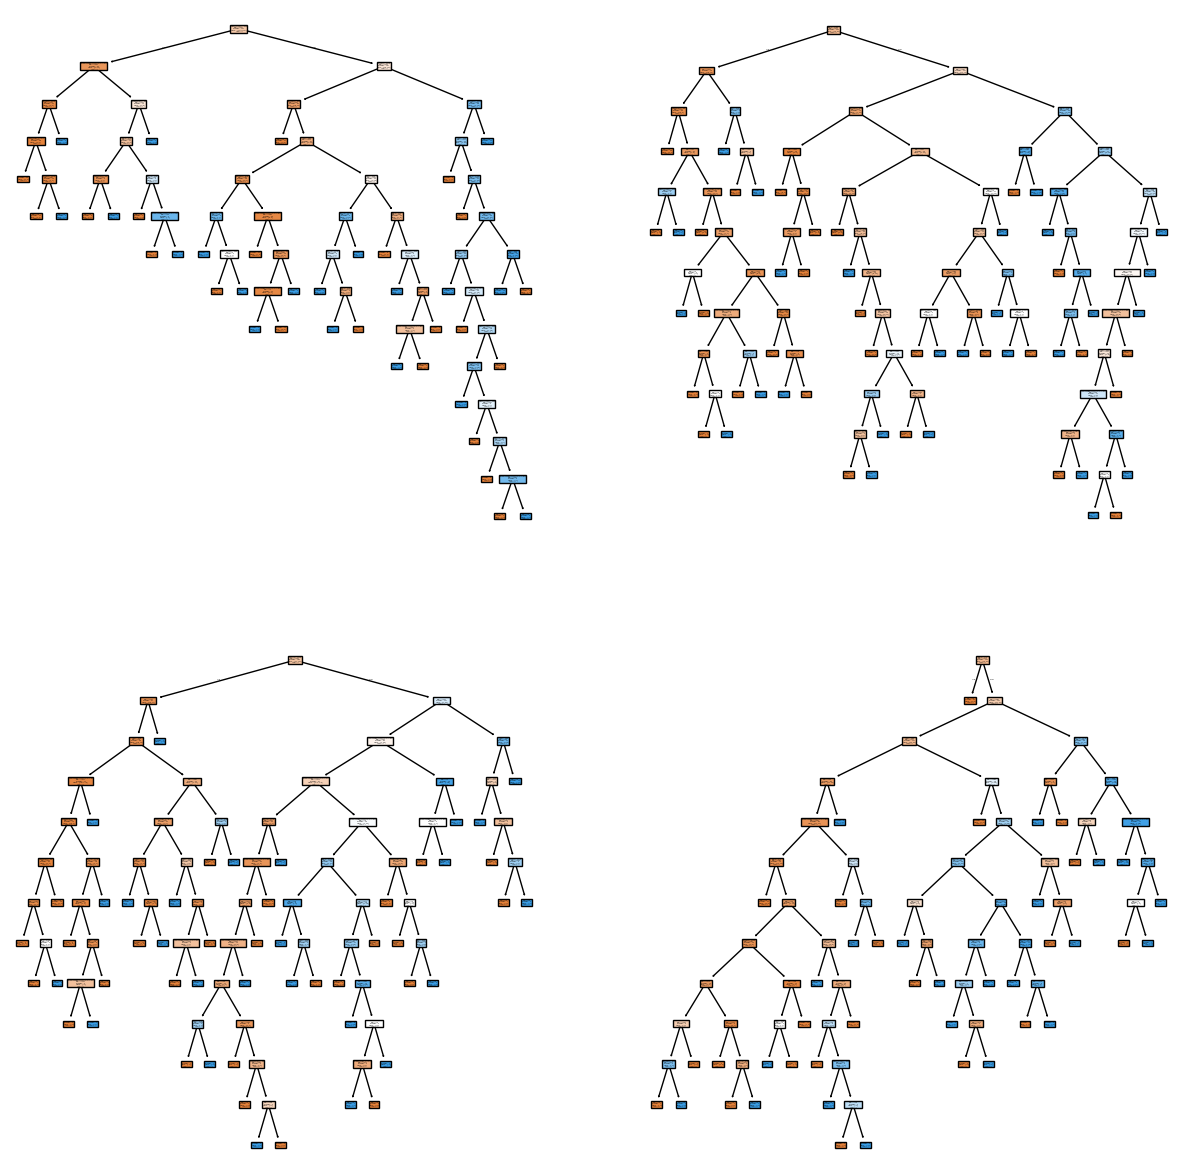

In [6]:
fig, axis = plt.subplots(2, 2, figsize = (15, 15))
tree.plot_tree(rf_classifier_model_filtrado.estimators_[0], ax = axis[0, 0], feature_names = list(X_train_filtrado.columns), class_names = ["0", "1", "2"], filled = True)
tree.plot_tree(rf_classifier_model_filtrado.estimators_[1], ax = axis[0, 1], feature_names = list(X_train_filtrado.columns), class_names = ["0", "1", "2"], filled = True)
tree.plot_tree(rf_classifier_model_filtrado.estimators_[2], ax = axis[1, 0], feature_names = list(X_train_filtrado.columns), class_names = ["0", "1", "2"], filled = True)
tree.plot_tree(rf_classifier_model_filtrado.estimators_[3], ax = axis[1, 1], feature_names = list(X_train_filtrado.columns), class_names = ["0", "1", "2"], filled = True)
plt.show()

#### Predicción 

In [7]:
y_pred_test_fil = rf_classifier_model_filtrado.predict(X_test_filtrado)
y_pred_test_fil

array([0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0])

In [8]:
y_pred_train_fil = rf_classifier_model_filtrado.predict(X_train_filtrado)
y_pred_train_fil

array([1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,

#### Matriz de confusión

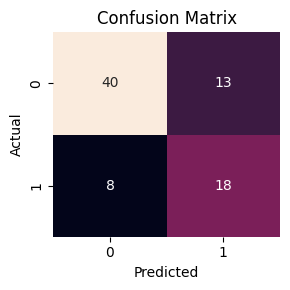

In [9]:
diabetes_cm = confusion_matrix(y_test_filtrado, y_pred_test_fil)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Métricas

In [10]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.734177,0.734177,0.734177,0.734177


In [11]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.734177,0.711829,0.706989,0.723512


In [12]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.00000,1.000000
Test set,0.734177,0.739256,0.75017,0.734177


## 2. Dataset con valores nulos remplazados por la moda

### Cargamos el dataset procedente del eda previo

In [13]:
df_train_mode = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-train-mode.csv")
df_test_mode = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-test-mode.csv")

### Generamos los conjuntos de train y test

In [14]:
X_train_mode = df_train_mode.drop(["Outcome"], axis = 1)
y_train_mode = df_train_mode["Outcome"]
X_test_mode = df_test_mode.drop(["Outcome"], axis = 1)
y_test_mode = df_test_mode["Outcome"]

### Modelado y Ajuste

In [15]:
rf_classifier_model_mode = RandomForestClassifier(random_state = 24)
rf_classifier_model_mode.fit(X_train_mode, y_train_mode)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Visualización de los árboles de decisión

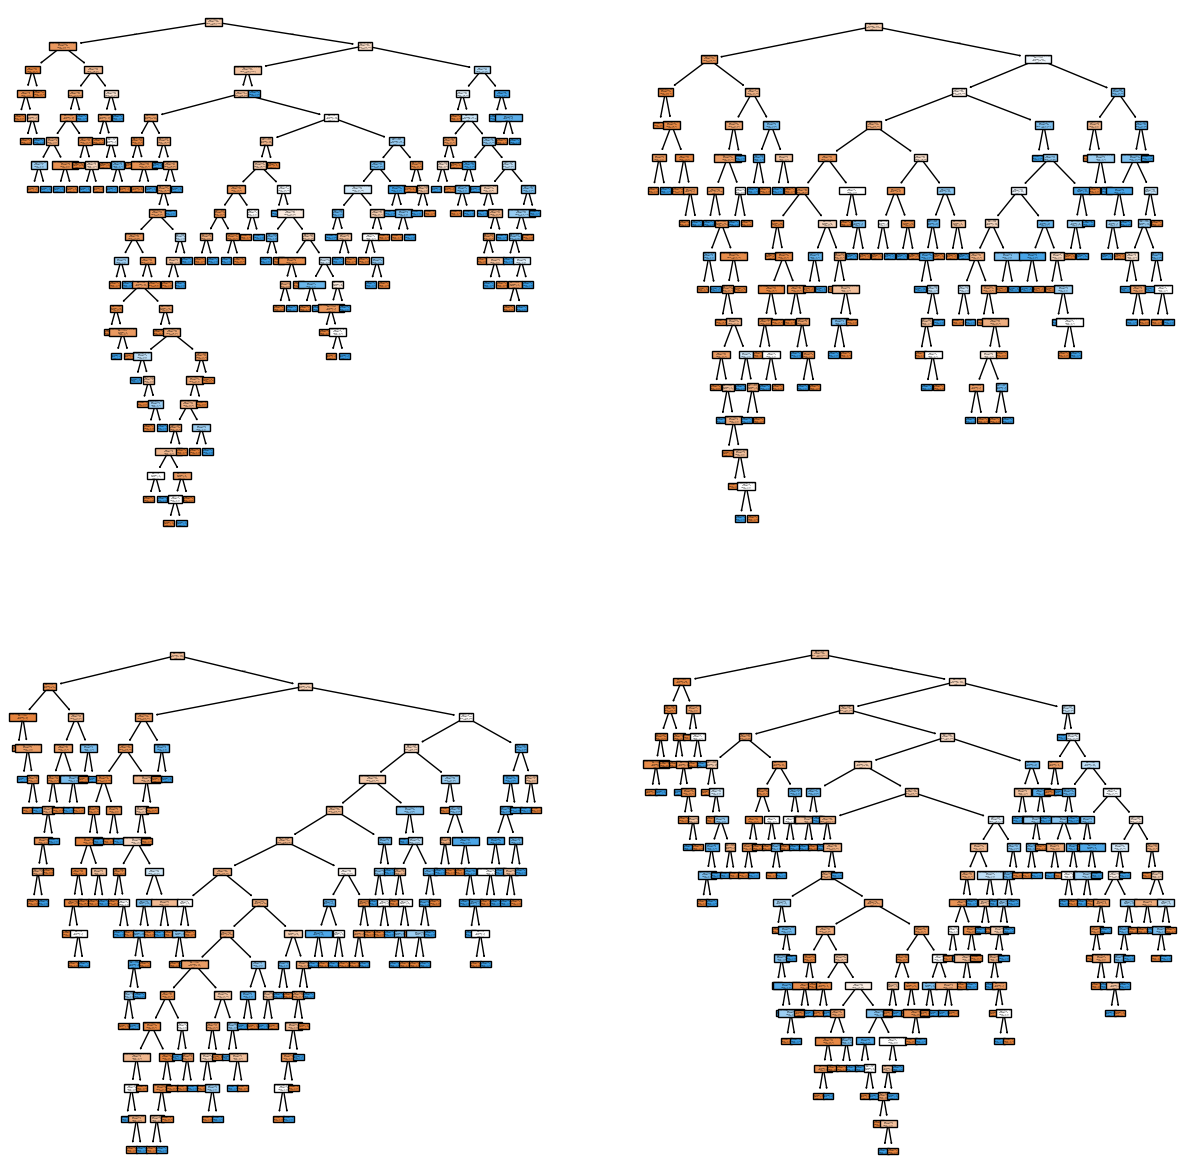

In [16]:
fig, axis = plt.subplots(2, 2, figsize = (15, 15))
tree.plot_tree(rf_classifier_model_mode.estimators_[0], ax = axis[0, 0], feature_names = list(X_train_mode.columns), class_names = ["0", "1", "2"], filled = True)
tree.plot_tree(rf_classifier_model_mode.estimators_[1], ax = axis[0, 1], feature_names = list(X_train_mode.columns), class_names = ["0", "1", "2"], filled = True)
tree.plot_tree(rf_classifier_model_mode.estimators_[2], ax = axis[1, 0], feature_names = list(X_train_mode.columns), class_names = ["0", "1", "2"], filled = True)
tree.plot_tree(rf_classifier_model_mode.estimators_[3], ax = axis[1, 1], feature_names = list(X_train_mode.columns), class_names = ["0", "1", "2"], filled = True)
plt.show()

#### Predicción 

In [17]:
y_pred_test_mode = rf_classifier_model_mode.predict(X_test_mode)
y_pred_test_mode

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [18]:
y_pred_train_mode = rf_classifier_model_mode.predict(X_train_mode)
y_pred_train_mode

array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,

#### Matriz de confusión

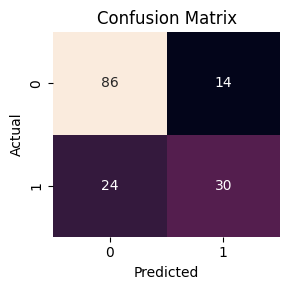

In [19]:
diabetes_cm = confusion_matrix(y_test_mode, y_pred_test_mode)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Métricas

In [20]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.753247,0.753247,0.753247,0.753247


In [21]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.753247,0.715646,0.731818,0.707778


In [22]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.753247,0.746532,0.746753,0.753247


## 3. Dataset con valores nulos remplazados por los k-nearest neighbors

In [23]:
df_train_kn = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-train-kn.csv")
df_test_kn = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-test-kn.csv")

### Generamos los conjuntos de train y test

In [24]:
X_train = df_train_kn.drop(["Outcome"], axis = 1)
y_train = df_train_kn["Outcome"]
X_test = df_test_kn.drop(["Outcome"], axis = 1)
y_test = df_test_kn["Outcome"]

### Modelado y Ajuste

In [25]:
rf_classifier_model = RandomForestClassifier(random_state = 24)
rf_classifier_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Visualización de los árboles de decisión

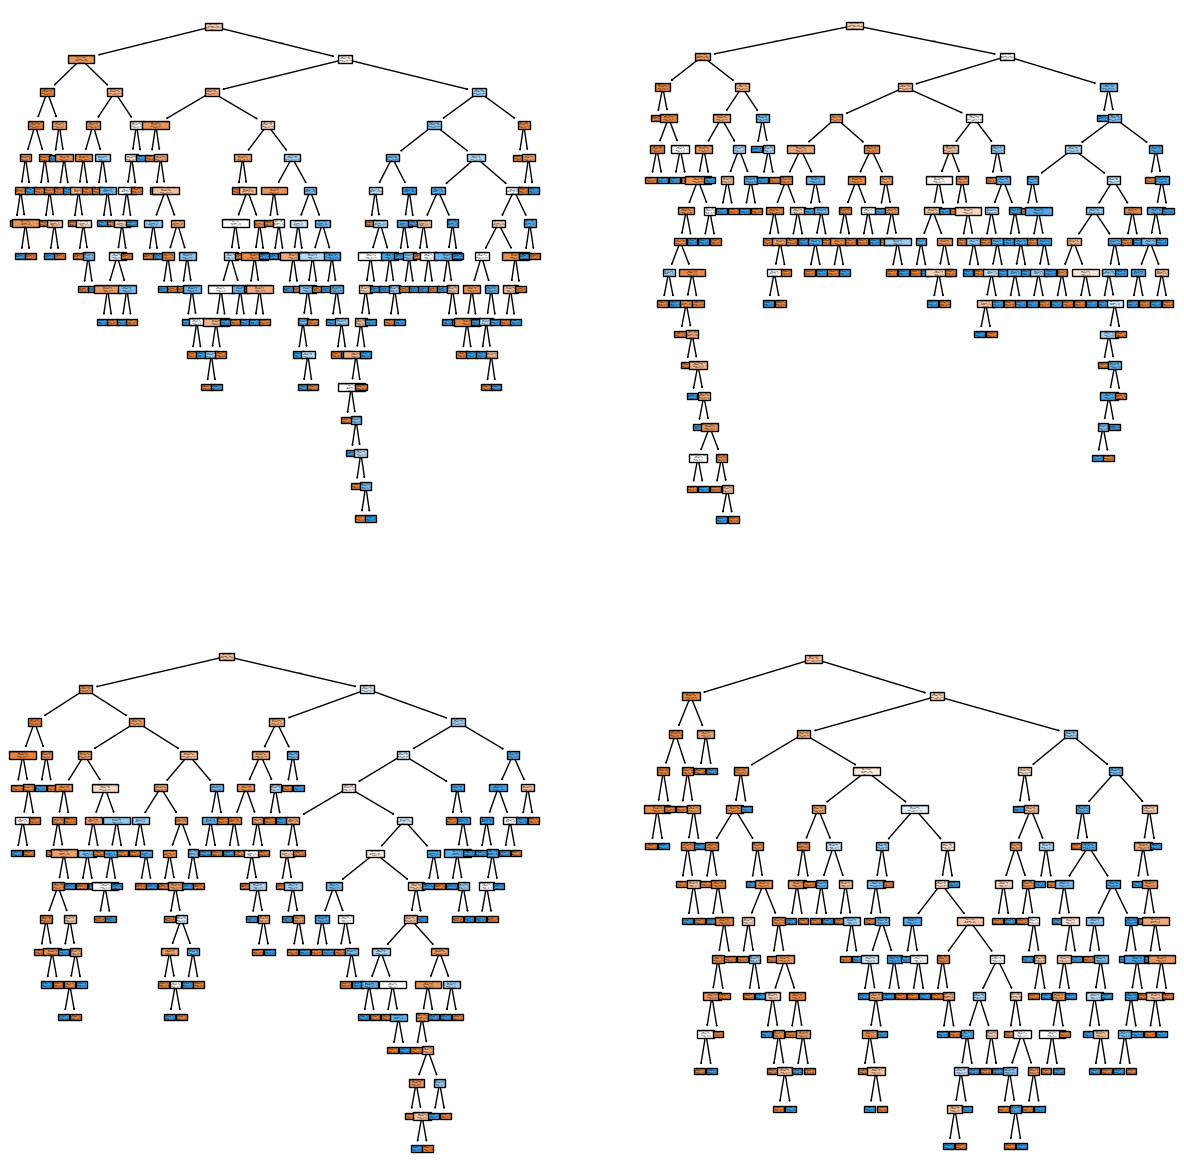

In [26]:
fig, axis = plt.subplots(2, 2, figsize = (15, 15))
tree.plot_tree(rf_classifier_model.estimators_[0], ax = axis[0, 0], feature_names = list(X_train.columns), class_names = ["0", "1", "2"], filled = True)
tree.plot_tree(rf_classifier_model.estimators_[1], ax = axis[0, 1], feature_names = list(X_train.columns), class_names = ["0", "1", "2"], filled = True)
tree.plot_tree(rf_classifier_model.estimators_[2], ax = axis[1, 0], feature_names = list(X_train.columns), class_names = ["0", "1", "2"], filled = True)
tree.plot_tree(rf_classifier_model.estimators_[3], ax = axis[1, 1], feature_names = list(X_train.columns), class_names = ["0", "1", "2"], filled = True)
plt.show()

#### Predicción 

In [27]:
y_pred_test = rf_classifier_model.predict(X_test)
y_pred_test

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0.,
       1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1.,
       0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 1., 0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 0.,
       1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
       0.])

In [28]:
y_pred_train = rf_classifier_model.predict(X_train)
y_pred_train

array([1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0.,
       1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 1.,
       0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1.,
       0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 0., 1., 1.,
       1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0.,
       1., 1., 0., 1., 0., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 0., 0., 1., 0., 0.,
       1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
       1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 0., 1., 0.

#### Matriz de confusión

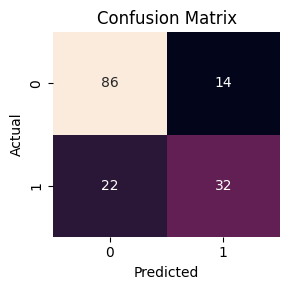

In [29]:
diabetes_cm = confusion_matrix(y_test, y_pred_test)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Métricas

In [30]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.766234,0.766234,0.766234,0.766234


In [31]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.766234,0.733462,0.745974,0.726296


In [32]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.766234,0.761379,0.761006,0.766234


## Conclusiones:

>- Después de varias pruebas, a profundidad máxima observamos que el modelo sufre overfitting (las métricas de train son perfectas)
>- El modelo mejora en el caso de los KNN respecto al del dataset con valores eliminados
>- Sin embargo no hay una mejora significativa con este modelo respecto al caso anterior de decision tree
>- Procedemos a la búsqueda de los mejores parámetros

## Buscamos los mejores parámetros con `GridSearchCV`

### Definición de parámetros y métricas

In [33]:
param_grid = {'n_estimators': [100, 200, 300],
              'max_depth': [3, 5, 7, None],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4],
              'max_features': ['sqrt', 'log2', None]
}
grid_search = GridSearchCV(estimator=rf_classifier_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=1
)


#### Entrenamiento de la cuadrícula

In [34]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,estimator,RandomForestC...ndom_state=24)
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


#### Mejores parámetros

In [35]:
grid_search.best_estimator_

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
grid_search.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'n_estimators': 300}

#### Predicción 

In [37]:
best_model = grid_search.best_estimator_
y_pred_test_grid = best_model.predict(X_test)
y_pred_test_grid

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0.,
       1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 0.,
       1., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0.,
       1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
       0.])

In [38]:
y_pred_train_grid = best_model.predict(X_train)
y_pred_train_grid

array([1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0.,
       0., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 1.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1., 1.,
       0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 1.,
       1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0.,
       0., 1., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0.,
       1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
       1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 1., 0.

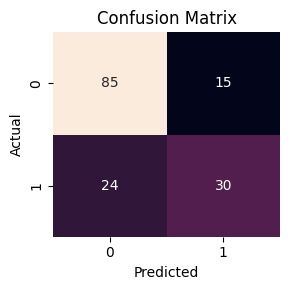

In [39]:
diabetes_cm = confusion_matrix(y_test, y_pred_test_grid)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Métricas

In [40]:
get_classifier_metrics(y_pred_test_grid, y_test, y_pred_train_grid, y_train) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.956026,0.956026,0.956026,0.956026
Test set,0.746753,0.746753,0.746753,0.746753


In [41]:
get_classifier_metrics(y_pred_test_grid, y_test, y_pred_train_grid, y_train, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.956026,0.950629,0.960931,0.942348
Test set,0.746753,0.709729,0.723242,0.702778


In [42]:
get_classifier_metrics(y_pred_test_grid, y_test, y_pred_train_grid, y_train, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.956026,0.955574,0.956784,0.956026
Test set,0.746753,0.740695,0.740141,0.746753


## Comparativa entre modelos

In [43]:
metricas = {'recall filtrado': recall_score(y_test_filtrado, y_pred_test_fil, average='micro'),
            'recall mode': recall_score(y_test_mode, y_pred_test_mode, average='micro'),
            'recall knn': recall_score(y_test, y_pred_test, average='micro'),
            'recall gridsearch': recall_score(y_test, y_pred_test_grid, average='micro')
           
}
metricas

{'recall filtrado': 0.7341772151898734,
 'recall mode': 0.7532467532467533,
 'recall knn': 0.7662337662337663,
 'recall gridsearch': 0.7467532467532467}

| Modelo           | Recall             |
|------------------|--------------------|
| KNN              | 0.7662             |
| Mode             | 0.7532             |
| GridSearch       | 0.7468             |
| Filtrado         | 0.7342             |


## Conclusiones:

>- Utilizando un modelo de random forest mejora el caso de KNN neighbors, pero el porcentaje no es muy grande en comparación. No me parece significativa la mejora para el coste computacional que implica.
>- Creo que podemos concluir que la calidad y cantidad de los datos o la división no son "suficientes" para generar un modelo robuzto y eficiente que sea capaz de predecir con más precisión

## Guardado de modelos

In [44]:
models = {'rf_classifier_model_filtrado' : rf_classifier_model_filtrado,
          'rf_classifier_model_mode' : rf_classifier_model_mode,
          'rf_classifier_model' : rf_classifier_model  
          }
with open('C:/Users/Simón/sayons-intro-ml-new/models/modelos-random-forest.pkl', 'wb') as file:
    pickle.dump(models, file)